# AIM · 2주차 리더용 자율 과제 해설
## CNN ② 성능을 개선하는 실험

**대상:** Python·PyTorch 기초 이수자 / **권장:** Google Colab Python 3, GPU 선택 가능.

1주차 CNN과 학습 루프를 복습한다. CIFAR10은 최초 약 170MB 다운로드가 필요하다. 학습 데이터 일부와 작은 모델로 시작하며 고성능 벤치마크 재현을 목표로 하지 않는다.

### 학습 목표
- CIFAR10에서 증강과 정규화의 역할을 구분한다.
- Residual block을 구현하고 공정한 비교 실험을 한다.
- 오분류·클래스별 성능·일반화 간격으로 결과를 해석한다.

### 실행 방법
1. Colab에서 `파일 → 노트북 업로드`로 이 파일을 엽니다.
2. GPU를 사용할 경우 `런타임 → 런타임 유형 변경`에서 GPU를 선택합니다.
3. 위에서 아래로 셀을 실행합니다. 이전 주차 파일이나 별도 Python 모듈은 필요 없습니다.
4. Colab 기본 torch·torchvision을 우선 사용합니다. import가 실패하면 새 런타임에서 시작하세요.
   로컬 환경은 루트 `환경설정.md`를 참고하세요. 데이터 최초 다운로드에는 인터넷이 필요합니다.
5. 학습이 길면 `TRAIN_N`, `EPOCHS` 또는 `STEPS`를 줄입니다. 작은 실험의 품질은 보장되지 않습니다.

**시간 운영:** 실습 셀 번호가 아니라 아래 § 구간으로 진행합니다. 준비·다운로드는 수업 시작에,
핵심 실행은 50–75분에, 관찰 답변은 75–85분에 수행합니다. 심화와 자율 과제는 수업 밖에서 진행합니다.

**재현성:** 고정 seed도 다른 GPU·라이브러리 버전의 완전히 같은 수치를 보장하지 않습니다.
실제 출력과 예측을 구분해 기록하세요. `outputs/`는 현재 실행 폴더에 생성됩니다.

### 자율 과제 안내

**A·B 기본 / C 비교 실험 / D 도전**입니다. 모두 선택이며 전부 하면 약 80–130분과 학습 시간이 필요합니다.
한 문제만 골라도 괜찮습니다. 이 노트북은 실습 파일 실행 없이 독립적으로 시작할 수 있습니다.

준비 코드는 제공하고, 아래 TODO 함수에 직접 구현합니다. 미완성 상태의 `return None`은 실행을 중단하지 않고 안내만 출력합니다.
코드를 작성하면 바로 다음 검사 셀을 실행하세요. 검사는 최소 계약만 확인하며 좋은 실험 해석을 자동 채점하지 않습니다.

**제출을 선택한다면:** 실행 결과가 남은 ipynb, 비교 표·그림, 아래 해석 5문장을 저장하세요.
test로 과제 조건을 반복 선택하지 말고 validation을 사용하세요.

## §1 · 환경 확인

첫 실행에서 버전과 device를 확인합니다. CPU도 지원하며 설치가 필요한 경우 환경설정 문서를 먼저 읽습니다.

In [1]:
import os, sys, math, random, copy, time, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms
from IPython.display import display

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# QUICK=True: 수업용 일부 데이터. False: 데이터/학습 예산 확대.
QUICK = True
# 검증 제작자용 축소 모드. 수강생은 설정할 필요가 없습니다.
SMOKE = os.environ.get('AIM_SMOKE', '0') == '1'
DATA_ROOT = Path(os.environ.get('AIM_DATA_ROOT', './data'))
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
torch.set_num_threads(min(4, os.cpu_count() or 1))

def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_all()
print('Python', sys.version.split()[0], '| torch', torch.__version__,
      '| torchvision', torchvision.__version__, '| device', DEVICE)
print('QUICK:', QUICK, '| SMOKE:', SMOKE, '| data:', DATA_ROOT.resolve())

def image_grid(images, titles=None, cols=8, title='', normalized=False):
    images = images.detach().cpu()
    if normalized: images = (images * .5 + .5).clamp(0, 1)
    n = len(images); rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.35, rows*1.55), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis('off')
        if i < n:
            im = images[i]
            ax.imshow(im.squeeze(0) if im.shape[0]==1 else im.permute(1,2,0),
                      cmap='gray', vmin=0, vmax=1)
            if titles is not None: ax.set_title(str(titles[i]), fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    return fig

def num_params(model): return sum(p.numel() for p in model.parameters() if p.requires_grad)

def cpu_state(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

Python 3.13.9 | torch 2.14.0+cpu | torchvision 0.29.0+cpu | device cpu
QUICK: True | SMOKE: False | data: D:\AIM\.study-data


In [2]:
DATASET = 'cifar'
TRAIN_N = 256 if SMOKE else (4096 if QUICK else 40000)
VAL_N = 128 if SMOKE else (1024 if QUICK else 5000)
TEST_N = 128 if SMOKE else (1024 if QUICK else 10000)
BATCH = 64 if SMOKE else 128
EPOCHS = 1 if SMOKE else (3 if QUICK else 15)

## §2 · 데이터와 분할

공식 train을 고정 인덱스로 나누고 test는 마지막에만 사용합니다. QUICK의 평가 숫자는 전체 공식 test의 성능이 아닌 고정 부분집합 성능입니다. MNIST 계열은 0~1, CIFAR10만 -1~1로 변환합니다.

split sizes: 4096 1024 1024
shape: torch.Size([128, 3, 32, 32]) dtype: torch.float32 range: (-1.0, 1.0)


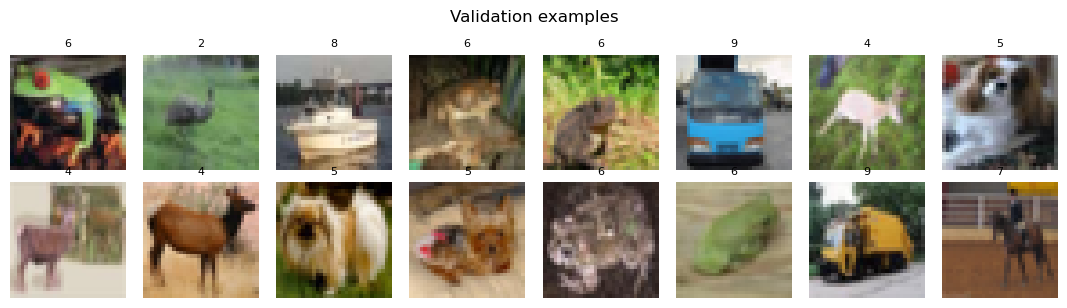

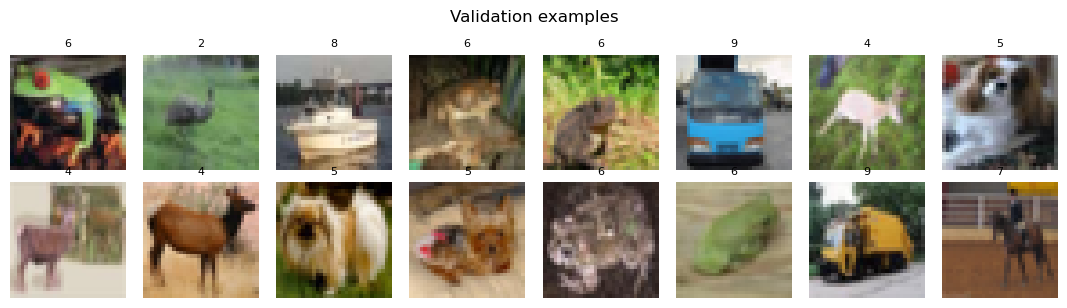

In [3]:
# DATASET은 앞의 설정 셀에서 지정합니다.train/valは公式trainから分割。
def vision_loaders(name, augment=False):
    cls = {'fashion':datasets.FashionMNIST, 'cifar':datasets.CIFAR10, 'mnist':datasets.MNIST}[name]
    base = [transforms.ToTensor()]
    if name=='cifar': base += [transforms.Normalize((.5,)*3, (.5,)*3)]
    eval_tf = transforms.Compose(base)
    train_tf = transforms.Compose(([transforms.RandomCrop(32,padding=4),
                                    transforms.RandomHorizontalFlip()] if augment else []) + base)
    train_ds = cls(DATA_ROOT, train=True, download=True, transform=train_tf)
    val_ds = cls(DATA_ROOT, train=True, download=True, transform=eval_tf)
    test_ds = cls(DATA_ROOT, train=False, download=True, transform=eval_tf)
    ids = torch.randperm(len(train_ds), generator=torch.Generator().manual_seed(SEED))
    n_val = 5000 if name=='cifar' else 6000
    train_ids = ids[n_val:][:TRAIN_N].tolist()
    val_ids = ids[:n_val][:VAL_N].tolist()
    test_ids = torch.randperm(len(test_ds), generator=torch.Generator().manual_seed(SEED+1))[:TEST_N].tolist()
    assert not (set(train_ids) & set(val_ids))
    train = DataLoader(Subset(train_ds,train_ids), batch_size=BATCH, shuffle=True,
                       generator=torch.Generator().manual_seed(SEED), num_workers=0)
    val = DataLoader(Subset(val_ds,val_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    test = DataLoader(Subset(test_ds,test_ids), batch_size=BATCH, shuffle=False, num_workers=0)
    return train,val,test

train_loader, val_loader, test_loader = vision_loaders(DATASET)
xb,yb = next(iter(val_loader))
print('split sizes:', *(len(dl.dataset) for dl in [train_loader,val_loader,test_loader]))
print('shape:', xb.shape, 'dtype:', xb.dtype, 'range:', (xb.min().item(),xb.max().item()))
image_grid(xb[:16], yb[:16].tolist(), title='Validation examples', normalized=DATASET=='cifar')

## §3 · 분류 모델 정의

모델 코드의 각 층 옆에 입출력 shape를 손으로 적어 보세요. MLP/SmallCNN은 FashionMNIST용, CifarCNN은 컬러 이미지용입니다.

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(),nn.Linear(784,128),nn.ReLU(),nn.Linear(128,10))
    def forward(self,x): return self.net(x)

class SmallCNN(nn.Module):
    def __init__(self,width=16,kernel=3):
        super().__init__()
        assert kernel % 2 == 1
        self.features=nn.Sequential(
            nn.Conv2d(1,width,kernel,padding=kernel//2),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(width,width*2,kernel,padding=kernel//2),nn.ReLU(),nn.MaxPool2d(2))
        self.classifier=nn.Sequential(nn.Flatten(),nn.Linear(width*2*7*7,64),nn.ReLU(),nn.Linear(64,10))
    def forward(self,x): return self.classifier(self.features(x))

class ResidualBlock(nn.Module):
    def __init__(self,cin,cout,stride=1):
        super().__init__()
        self.body=nn.Sequential(nn.Conv2d(cin,cout,3,stride,1,bias=False),nn.BatchNorm2d(cout),nn.ReLU(),
                                nn.Conv2d(cout,cout,3,1,1,bias=False),nn.BatchNorm2d(cout))
        self.skip=nn.Identity() if cin==cout and stride==1 else nn.Sequential(
            nn.Conv2d(cin,cout,1,stride,bias=False),nn.BatchNorm2d(cout))
    def forward(self,x): return F.relu(self.body(x)+self.skip(x))

class CifarCNN(nn.Module):
    def __init__(self,residual=False):
        super().__init__()
        layers=[nn.Conv2d(3,32,3,padding=1,bias=False),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2)]
        if residual: layers += [ResidualBlock(32,64,stride=2)]
        else: layers += [nn.Conv2d(32,64,3,padding=1,bias=False),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2)]
        self.features=nn.Sequential(*layers,nn.AdaptiveAvgPool2d(1))
        self.head=nn.Linear(64,10)
    def forward(self,x): return self.head(self.features(x).flatten(1))

## §4 · 공통 학습·평가 함수

샘플 수 가중 평균, eval/no_grad, 최고 validation checkpoint 복사를 확인합니다.

In [5]:
def classification_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training); total=correct=count=0
    all_y=[]; all_pred=[]
    with torch.set_grad_enabled(training):
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            logits=model(x); loss=F.cross_entropy(logits,y)
            assert torch.isfinite(loss), 'loss is not finite'
            if training: loss.backward(); optimizer.step()
            n=len(y); total+=loss.item()*n; count+=n
            pred=logits.argmax(1); correct+=(pred==y).sum().item()
            all_y.append(y.detach().cpu()); all_pred.append(pred.detach().cpu())
    return dict(loss=total/count,accuracy=correct/count,
                y=torch.cat(all_y),pred=torch.cat(all_pred))

def fit_classifier(factory,loader,epochs=EPOCHS):
    seed_all(); model=factory().to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=1e-3,weight_decay=1e-4)
    history=[]; best_loss=float('inf'); best=None; start=time.perf_counter()
    for ep in range(epochs):
        tr=classification_epoch(model,loader,opt); va=classification_epoch(model,val_loader)
        history.append(dict(epoch=ep+1,train_loss=tr['loss'],val_loss=va['loss'],val_acc=va['accuracy']))
        if va['loss']<best_loss: best_loss=va['loss']; best=cpu_state(model)
        print(f"epoch {ep+1}: train={tr['loss']:.3f} val={va['loss']:.3f} acc={va['accuracy']:.3f}")
    model.load_state_dict(best)
    return model,history,time.perf_counter()-start

def plot_classification(histories):
    fig,axes=plt.subplots(1,2,figsize=(10,3))
    for name,h in histories.items():
        axes[0].plot([r['epoch'] for r in h],[r['train_loss'] for r in h],label=name+' train')
        axes[0].plot([r['epoch'] for r in h],[r['val_loss'] for r in h],'--',label=name+' val')
        axes[1].plot([r['epoch'] for r in h],[r['val_acc'] for r in h],label=name)
    axes[0].set_title('Cross entropy'); axes[1].set_title('Validation accuracy')
    for ax in axes: ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=.2)
    plt.tight_layout(); plt.show()

def confusion(y,pred,nclass=10):
    return torch.bincount(y*nclass+pred,minlength=nclass*nclass).reshape(nclass,nclass)

def inspect_classifier(model):
    result=classification_epoch(model,val_loader)
    cm=confusion(result['y'],result['pred'])
    fig,ax=plt.subplots(figsize=(5,4)); im=ax.imshow(cm,cmap='Blues')
    ax.set(xlabel='predicted',ylabel='true',xticks=range(10),yticks=range(10))
    fig.colorbar(im,ax=ax); plt.show()
    recall=cm.diag().float()/cm.sum(1).clamp_min(1)
    print('class counts:',cm.sum(1).tolist()); print('recall:',recall.tolist())
    wrong=(result['y']!=result['pred']).nonzero().flatten()[:8]
    if len(wrong):
        imgs=torch.stack([val_loader.dataset[i.item()][0] for i in wrong])
        labels=[f"true={result['y'][i]} pred={result['pred'][i]}" for i in wrong]
        image_grid(imgs,labels,title='Validation errors',normalized=DATASET=='cifar')
    else: print('No error in this validation subset; inspect a larger subset.')
    return cm

## A · projection shortcut / 15분

cin=32, cout=64, stride=2인 입력 경로를 만들 수 있는 shortcut 함수를 작성하세요. shape가 같으면 Identity를 반환하세요.

In [6]:
def make_shortcut(cin,cout,stride=1):
    if cin==cout and stride==1: return nn.Identity()
    return nn.Sequential(nn.Conv2d(cin,cout,1,stride,bias=False),nn.BatchNorm2d(cout))

In [7]:
shortcut=make_shortcut(32,64,2)
if shortcut is None: print('미완성: A를 구현하세요.')
else:
    assert shortcut(torch.randn(2,32,16,16)).shape==(2,64,8,8)
    assert isinstance(make_shortcut(32,32),nn.Identity)
    print('PASS A')

PASS A


**참고 해설**

projection은 채널과 공간 stride를 함께 맞춥니다. 1×1 Conv에도 stride=2를 적용해야 합니다. Identity에는 학습 파라미터가 없습니다.

## B · 클래스별 recall / 15분

행=true, 열=pred인 confusion matrix에서 recall과 macro recall을 반환하세요. 실제 표본이 없는 클래스는 NaN으로 두고 macro 평균에서 제외하세요.

In [8]:
def class_recall(cm):
    support=cm.sum(1); recall=cm.diag().float()/support.clamp_min(1)
    recall[support==0]=float('nan')
    return recall,torch.nanmean(recall).item()

In [9]:
r=class_recall(torch.tensor([[3,1,0],[2,2,0],[0,0,0]]))
if r is None: print('미완성: B를 구현하세요.')
else:
    recalls,macro=r
    torch.testing.assert_close(recalls[:2],torch.tensor([.75,.5]))
    assert torch.isnan(recalls[2]) and abs(macro-.625)<1e-6
    print('PASS B:',r)

PASS B: (tensor([0.7500, 0.5000,    nan]), 0.625)


**참고 해설**

정답 클래스의 전체 개수는 행 합입니다. 빈 클래스를 0으로 넣으면 macro recall을 부당하게 낮춥니다. precision은 열 합을 분모로 쓰는 다른 지표입니다.

## C · residual on/off / 35–50분

증강을 켠 동일한 loader로 CifarCNN(residual=False/True)를 새로 학습하세요. 조건·파라미터 수·시간·val loss·val accuracy를 기록하세요.

In [10]:
def residual_experiment():
    rows=[]
    for residual in [False,True]:
        loader,_,_=vision_loaders('cifar',augment=True)
        m,h,seconds=fit_classifier(lambda:CifarCNN(residual=residual),loader)
        r=classification_epoch(m,val_loader)
        rows.append(dict(residual=residual,params=num_params(m),seconds=seconds,val_loss=r['loss'],val_acc=r['accuracy']))
    return rows

In [11]:
rows=residual_experiment()
if rows is None: print('미완성: C를 작성하세요.')
else:
    assert {r['residual'] for r in rows}=={False,True}
    assert all(np.isfinite(r['val_loss']) and r['seconds']>0 for r in rows)
    display(rows)

epoch 1: train=2.109 val=2.048 acc=0.260
epoch 2: train=1.965 val=1.914 acc=0.314
epoch 3: train=1.898 val=1.849 acc=0.342
epoch 1: train=2.055 val=2.027 acc=0.217
epoch 2: train=1.851 val=1.768 acc=0.318
epoch 3: train=1.735 val=1.669 acc=0.354


[{'residual': False,
  'params': 20138,
  'seconds': 5.618506300263107,
  'val_loss': 1.849261611700058,
  'val_acc': 0.341796875},
 {'residual': True,
  'params': 59306,
  'seconds': 4.759638799820095,
  'val_loss': 1.668840691447258,
  'val_acc': 0.3544921875}]

**참고 해설**

이 비교는 skip 경로뿐 아니라 블록의 Conv 수와 파라미터 수도 바뀝니다. 따라서 residual 연결만의 인과 효과를 분리한 실험은 아닙니다. 순수 연결 효과를 보려면 동일 body에서 덧셈만 on/off하는 후속 실험을 설계하세요.

## D · 순수 skip ablation 설계 / 30–45분

입출력 shape가 같은 두 Conv body를 두고 skip=True/False만 바뀌는 블록을 작성하세요. 같은 state_dict에서 F(x)와 F(x)+x를 비교할 수 있어야 합니다.

In [12]:
def make_ablation_block(skip=True):
    class AblationBlock(nn.Module):
        def __init__(self):
            super().__init__(); self.skip=skip
            self.body=nn.Sequential(nn.Conv2d(32,32,3,padding=1),nn.ReLU(),nn.Conv2d(32,32,3,padding=1))
        def forward(self,x): return self.body(x)+(x if self.skip else 0)
    return AblationBlock()

In [13]:
a=make_ablation_block(True)
if a is None: print('미완성: D는 도전 과제입니다.')
else:
    b=make_ablation_block(False); b.load_state_dict(a.state_dict())
    x=torch.randn(2,32,8,8)
    torch.testing.assert_close(a(x)-b(x),x)
    assert num_params(a)==num_params(b)
    print('PASS D: same body and parameter count')

PASS D: same body and parameter count


**참고 해설**

이 블록은 비교를 선명하게 하기 위해 덧셈 뒤 ReLU를 생략합니다. 파라미터 수와 body가 같으므로 skip만 바뀝니다. 실제 학습 비교를 확장할 때 분할·초기화·예산도 고정합니다.

## 비교 실험 해석 · 5문장 필수 틀

1. 나의 질문과 바꾼 변수는 …
2. 고정한 조건(분할, seed, 예산, 평가)은 …
3. 실제 관측 결과는 … (숫자·그림 번호를 근거로)
4. 이 결과만으로 말할 수 없는 것은 …
5. 다음에 한 가지만 더 검증한다면 …

| 조건 | seed | 학습 예산 | params | validation 지표 | 시간 | 관찰 |
|---|---|---|---|---|---|---|
| 기준 | | | | | | |
| 변경 | | | | | | |

### 자기 점검 기준 (100점 환산, 성적 부여 목적 아님)
- 구현의 shape·수식·gradient·mask 계약 30
- 통제 조건과 재현 가능한 코드 25
- 실제 결과 표·그림과 실패 사례 25
- 과장 없는 해석과 한계·후속 실험 20

고정 정확도나 생성 품질 기준은 없습니다. 개선되지 않은 실험도 근거를 잘 남기면 좋은 결과물입니다.

## 리더 진행 팁

A·B의 검사 통과 후 식과 축을 말로 설명하게 합니다. C·D의 성능 숫자는 정답이 아닙니다. 비교 조건이 바뀐 부분을 먼저 찾고, 실제 출력과 관찰을 근거로 해석했는지 확인하세요.